# SEMIR Pancreas Tumor Detection

**What this notebook does**: Runs the SEMIR graph minor pipeline on MSD Task07 Pancreas CT scans
and visualizes how it detects tumors — without needing the ground truth CSV files that
`vkg_from_csv.py` currently depends on.

**How SEMIR detection works (high level)**:

1. **Raw CT** (28M voxels) is intensity-windowed to [20, 180] HU to maximize pancreas/tumor contrast
2. **Edge contraction** groups neighboring voxels with similar intensity into "supernodes" (~1K total instead of 28M)
3. **Node deletion** removes supernodes that are too small or too large (noise filtering)
4. **Edge deletion** cuts connections between supernodes with very different intensities
5. Each surviving supernode gets **7 geometric features** (volume, compactness, elongation, intensity, etc.)
6. A **GINE classifier** (later) labels each supernode as tumor vs background
7. The tumor supernodes' features become the **phenotype measurements** the VKG needs

This notebook focuses on steps 1-5: can SEMIR produce supernodes that align with the tumor?

In [1]:
import sys, os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))
from semir.graph_minor import build_graph_minor
from semir.features import extract_node_features, extract_edge_features

DATA_ROOT = "/scratch/ud3d4/acm_data/Pancreas"
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 1. Load a pancreas case and inspect

Each case has:
- **CT volume** (`.nii.gz`): 3D array of Hounsfield Units (HU). Typical size ~512x512x100.
- **Segmentation mask**: 0 = background, 1 = pancreas organ, 2 = pancreatic cancer.

This is MSD Task07 — every case has exactly **one pancreas and one tumor** (1:1 mapping),
which makes it the simplest test for SEMIR since we don't need multi-tumor grouping.

In [2]:
CASE = "pancreas_001"

ct_nii = nib.load(os.path.join(DATA_ROOT, "imagesTr", f"{CASE}.nii.gz"))
seg_nii = nib.load(os.path.join(DATA_ROOT, "labelsTr", f"{CASE}.nii.gz"))

ct_raw = ct_nii.get_fdata().astype(np.float32)
seg = seg_nii.get_fdata().astype(np.int32)
spacing = tuple(float(s) for s in ct_nii.header.get_zooms()[:3])

print(f"Shape: {ct_raw.shape}, Spacing: {spacing} mm")
print(f"HU range: [{ct_raw.min():.0f}, {ct_raw.max():.0f}]")
print(f"Labels: 0=bg ({(seg==0).sum():,}), 1=pancreas ({(seg==1).sum():,}), 2=tumor ({(seg==2).sum():,})")
print(f"Tumor coverage: {(seg==2).sum()/(seg==1).sum()*100:.1f}%")

Shape: (512, 512, 110), Spacing: (0.6445310115814209, 0.6445310115814209, 2.5) mm
HU range: [-1024, 3071]
Labels: 0=bg (28,770,130), 1=pancreas (39,557), 2=tumor (26,153)
Tumor coverage: 66.1%


Best tumor slice: z=41 (2,011 tumor voxels)


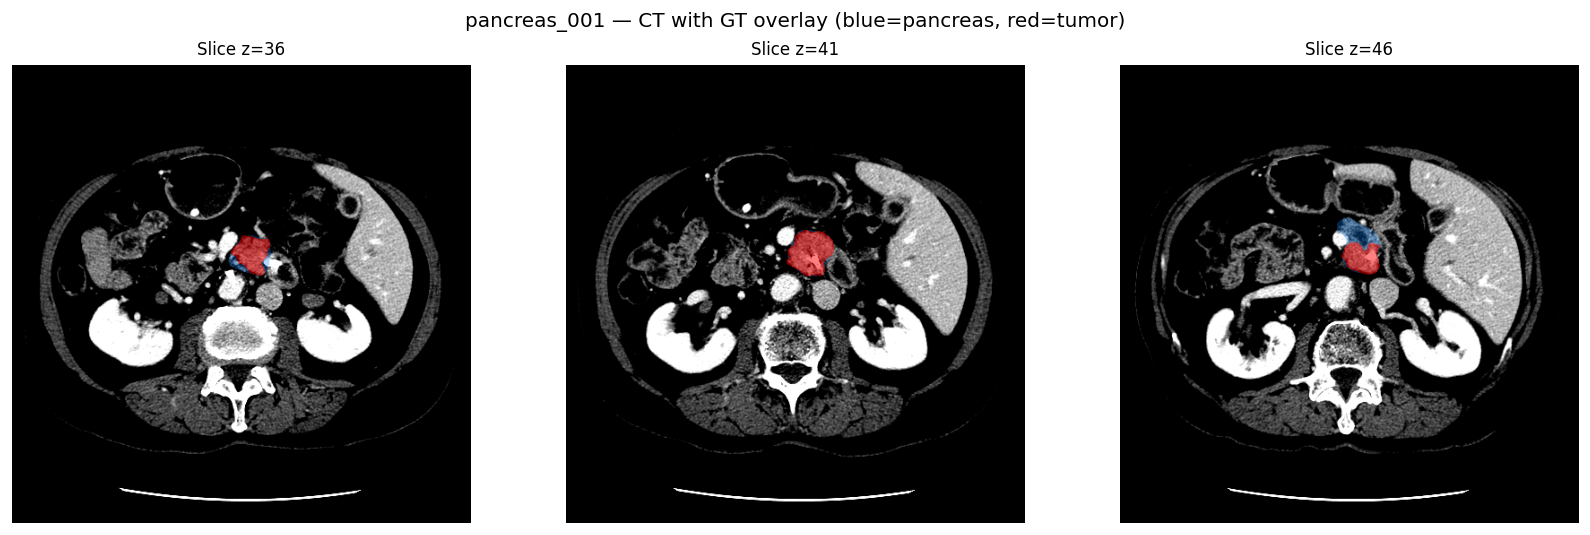

In [3]:
# Find the axial slice with the most tumor voxels — this is where
# the tumor cross-section is largest and easiest to see.
tumor_per_slice = (seg == 2).sum(axis=(0, 1))
best_slice = int(np.argmax(tumor_per_slice))
print(f"Best tumor slice: z={best_slice} ({tumor_per_slice[best_slice]:,} tumor voxels)")

# Show 3 slices: 5 below, the best, and 5 above — gives a sense of
# how the tumor extends through the volume in the z-direction.
slices = [max(0, best_slice - 5), best_slice, min(seg.shape[2]-1, best_slice + 5)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, sl in zip(axes, slices):
    ct_slice = ct_raw[:, :, sl]
    seg_slice = seg[:, :, sl]
    
    # Display CT windowed to [20, 180] HU — this is the narrow pancreas
    # window that maximizes contrast between pancreas tissue (~80-120 HU)
    # and tumor (~30-50 HU). Everything outside this range clips to black/white.
    ax.imshow(ct_slice.T, cmap="gray", vmin=20, vmax=180, origin="lower")
    
    # Overlay the ground truth segmentation:
    #   Blue = pancreas organ (label 1)
    #   Red  = tumor (label 2)
    overlay = np.zeros((*ct_slice.T.shape, 4))
    overlay[seg_slice.T == 1] = [0, 0.5, 1, 0.3]   # pancreas: blue, semi-transparent
    overlay[seg_slice.T == 2] = [1, 0, 0, 0.5]      # tumor: red, more opaque
    ax.imshow(overlay, origin="lower")
    ax.set_title(f"Slice z={sl}", fontsize=10)
    ax.axis("off")

fig.suptitle(f"{CASE} — CT with GT overlay (blue=pancreas, red=tumor)", fontsize=12)
plt.tight_layout()
plt.show()

## 2. SEMIR graph minor construction

This is where the "detection" actually happens. Three operations run in sequence:

### Edge contraction (psi = 0.12)
The 28M voxels are quantized into intensity bins of width `psi` (0.12 on a [0,1] scale = ~19 HU).
Within each bin, spatially connected voxels merge into a **supernode**. This is the key step —
voxels that look similar AND are next to each other become one unit.

**Why quantization matters**: Without it, gradual intensity changes create a chain that merges
the entire volume into one blob. Quantization puts hard walls between intensity ranges,
so tumor (HU ~30-50) and pancreas (HU ~80-120) land in **different bins** and stay separate.

### Node deletion (beta_min = 100)
Any supernode smaller than 100 voxels is deleted. This removes noise — tiny fragments from
partial-volume effects or intensity fluctuations. The trade-off: small tumors could be lost.

### Edge deletion (alpha = 0.12)
Connections between supernodes whose mean intensities differ by more than `alpha` are cut.
This cleans up the graph for the downstream GNN.

In [4]:
# Step 1: Normalize CT to [0, 1] using the narrow pancreas window.
# HU 20 -> 0.0, HU 180 -> 1.0. Anything outside clips.
# This means tumor (~30-50 HU) maps to ~0.06-0.19 and
# pancreas (~80-120 HU) maps to ~0.38-0.63 — a clear gap.
ct_norm = np.clip(ct_raw, 20, 180)
ct_norm = (ct_norm - 20) / 160.0

# Step 2: Build the graph minor. This runs all three operations:
#   edge contraction -> node deletion -> edge deletion
# The output is a label volume (same shape as CT) where each voxel
# is assigned to a supernode ID, plus an adjacency graph between supernodes.
import time
t0 = time.time()
gm = build_graph_minor(ct_norm, psi=0.12, alpha=0.12, beta_min=100,
                        beta_max=500000, m_min=0.0, m_max=1.0, fast=True)
dt = time.time() - t0

labels = gm["labels"]      # (H, W, D) array: voxel -> supernode ID (0 = deleted)
stats = gm["stats"]

print(f"Supernodes:  {stats['n_supernodes_after_deletion']:,}")  # target: ~1K (paper range)
print(f"Full edges:  {len(gm['full_adjacency']):,}")             # connections for GNN
print(f"Compression: {stats['compression_ratio']:,.0f}x")        # 28M -> ~1K = ~28,000x
print(f"Time:        {dt:.1f}s")

Supernodes:  1,040
Full edges:  1,463
Compression: 27,727x
Time:        11.0s


In [5]:
# Now we ask: did the supernodes land on the tumor?
# 
# We check each supernode's overlap with the GT segmentation.
# If >10% of a supernode's voxels are labeled "tumor" in the GT,
# we call it a "tumor supernode". Same logic for pancreas.
#
# NOTE: In the real pipeline, the GINE classifier does this job
# (no GT needed). Here we use GT just to EVALUATE how well
# the graph minor partitioned the tissue.

flat_labels = labels.ravel()
max_label = int(labels.max())
flat_gt_tumor = (seg.ravel() == 2).astype(np.float64)
flat_gt_pancreas = (seg.ravel() == 1).astype(np.float64)

# For each supernode: count total voxels and how many are tumor/pancreas
total_counts = np.bincount(flat_labels, minlength=max_label + 1)
tumor_counts = np.bincount(flat_labels, weights=flat_gt_tumor, minlength=max_label + 1)
pancreas_counts = np.bincount(flat_labels, weights=flat_gt_pancreas, minlength=max_label + 1)

safe = np.where(total_counts > 0, total_counts, 1)
tumor_frac = tumor_counts / safe       # fraction of each SN that is tumor
pancreas_frac = pancreas_counts / safe  # fraction that is pancreas

# Supernodes where >10% of voxels overlap with GT
tumor_sids = set(i for i in range(max_label+1) if total_counts[i] > 0 and tumor_frac[i] > 0.1)
pancreas_sids = set(i for i in range(max_label+1) if total_counts[i] > 0 and pancreas_frac[i] > 0.1)

print(f"Tumor supernodes (>10% overlap):    {len(tumor_sids)}")
print(f"Pancreas supernodes (>10% overlap): {len(pancreas_sids)}")
print(f"Tumor voxels captured: {sum(int(tumor_counts[i]) for i in tumor_sids):,} / {(seg==2).sum():,}")
print(f"Pancreas voxels captured: {sum(int(pancreas_counts[i]) for i in pancreas_sids):,} / {(seg==1).sum():,}")

Tumor supernodes (>10% overlap):    4
Pancreas supernodes (>10% overlap): 11
Tumor voxels captured: 1,365 / 26,153
Pancreas voxels captured: 1,450 / 39,557


## 3. Supernode boundaries vs GT — the key visualization

Three panels on the same slice:

- **Left (Ground Truth)**: What a radiologist labeled — the "answer" we're trying to match.
- **Middle (Supernode Boundaries)**: Green lines show where SEMIR drew boundaries between supernodes. Good boundaries should follow tissue edges (especially the tumor-pancreas boundary).
- **Right (SEMIR Detections)**: Which supernodes overlap with tumor (red) and pancreas (blue). This is what the GINE classifier needs to learn to predict.

**What to look for**: Do the green boundary lines in the middle panel align with the red-blue boundary in the left panel? If yes, the graph minor is partitioning tissue correctly and the GINE has a good chance of classifying supernodes accurately.

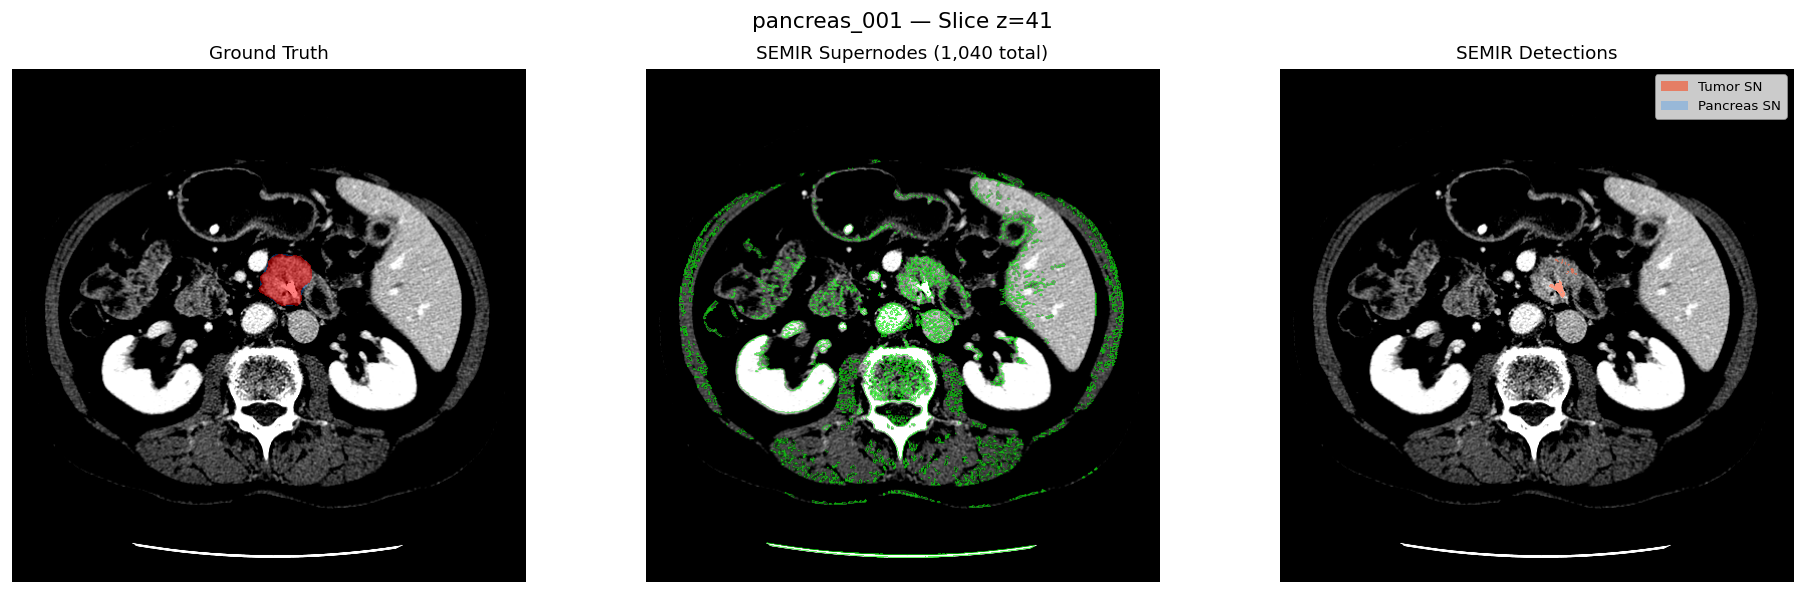

In [6]:
from scipy.ndimage import sobel

def supernode_boundary_2d(label_slice):
    """Get boundary pixels between different supernodes in a 2D slice."""
    if label_slice.max() == 0:
        return np.zeros_like(label_slice, dtype=bool)
    # Gradient in x and y — nonzero where label changes
    gx = np.diff(label_slice, axis=0, prepend=label_slice[0:1, :])
    gy = np.diff(label_slice, axis=1, prepend=label_slice[:, 0:1])
    return (gx != 0) | (gy != 0)

sl = best_slice
label_slice = labels[:, :, sl]
seg_slice = seg[:, :, sl]
ct_slice = ct_raw[:, :, sl]

# Build color map for tumor/pancreas supernodes
sn_class = np.zeros_like(label_slice, dtype=np.int32)
for y in range(label_slice.shape[0]):
    for x in range(label_slice.shape[1]):
        sid = label_slice[y, x]
        if sid in tumor_sids:
            sn_class[y, x] = 2  # tumor
        elif sid in pancreas_sids:
            sn_class[y, x] = 1  # pancreas

boundary = supernode_boundary_2d(label_slice)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: CT + GT
ax = axes[0]
ax.imshow(ct_slice.T, cmap="gray", vmin=20, vmax=180, origin="lower")
overlay_gt = np.zeros((*ct_slice.T.shape, 4))
overlay_gt[seg_slice.T == 1] = [0, 0.5, 1, 0.3]
overlay_gt[seg_slice.T == 2] = [1, 0, 0, 0.5]
ax.imshow(overlay_gt, origin="lower")
ax.set_title("Ground Truth", fontsize=11)
ax.axis("off")

# Panel 2: CT + supernode boundaries
ax = axes[1]
ax.imshow(ct_slice.T, cmap="gray", vmin=20, vmax=180, origin="lower")
boundary_overlay = np.zeros((*ct_slice.T.shape, 4))
boundary_overlay[boundary.T] = [0, 1, 0, 0.6]
ax.imshow(boundary_overlay, origin="lower")
ax.set_title(f"SEMIR Supernodes ({stats['n_supernodes_after_deletion']:,} total)", fontsize=11)
ax.axis("off")

# Panel 3: CT + detected tumor/pancreas supernodes
ax = axes[2]
ax.imshow(ct_slice.T, cmap="gray", vmin=20, vmax=180, origin="lower")
det_overlay = np.zeros((*ct_slice.T.shape, 4))
det_overlay[sn_class.T == 1] = [0, 0.5, 1, 0.25]   # pancreas SN: blue
det_overlay[sn_class.T == 2] = [1, 0.2, 0, 0.5]     # tumor SN: red
ax.imshow(det_overlay, origin="lower")
ax.set_title("SEMIR Detections", fontsize=11)
ax.legend(handles=[
    Patch(facecolor=(1, 0.2, 0, 0.5), label="Tumor SN"),
    Patch(facecolor=(0, 0.5, 1, 0.25), label="Pancreas SN"),
], loc="upper right", fontsize=8)
ax.axis("off")

fig.suptitle(f"{CASE} — Slice z={sl}", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Supernode feature analysis

Each supernode gets 7 features extracted purely from the voxel geometry and intensity — no GT used:

| Feature | What it measures | How it helps |
|---|---|---|
| **volume** | Number of voxels in the supernode | Tumor size — maps directly to CSV "Tumor Volume" |
| **compactness** | 36*pi*a^2/b^3 (surface-to-volume ratio) | Round blobs vs diffuse spread |
| **elongation** | PCA eigenvalue ratio (max/min) | Stretched vs spherical shape |
| **mean_intensity** | Average HU of voxels | Tumor is hypodense (~0.1) vs pancreas (~0.5) |
| **intensity_std** | HU variation within supernode | Heterogeneous tumors have high std |

The histograms below show whether tumor supernodes are **separable** from background on these features.
If the red and gray distributions don't overlap much, the GINE can learn the boundary easily.

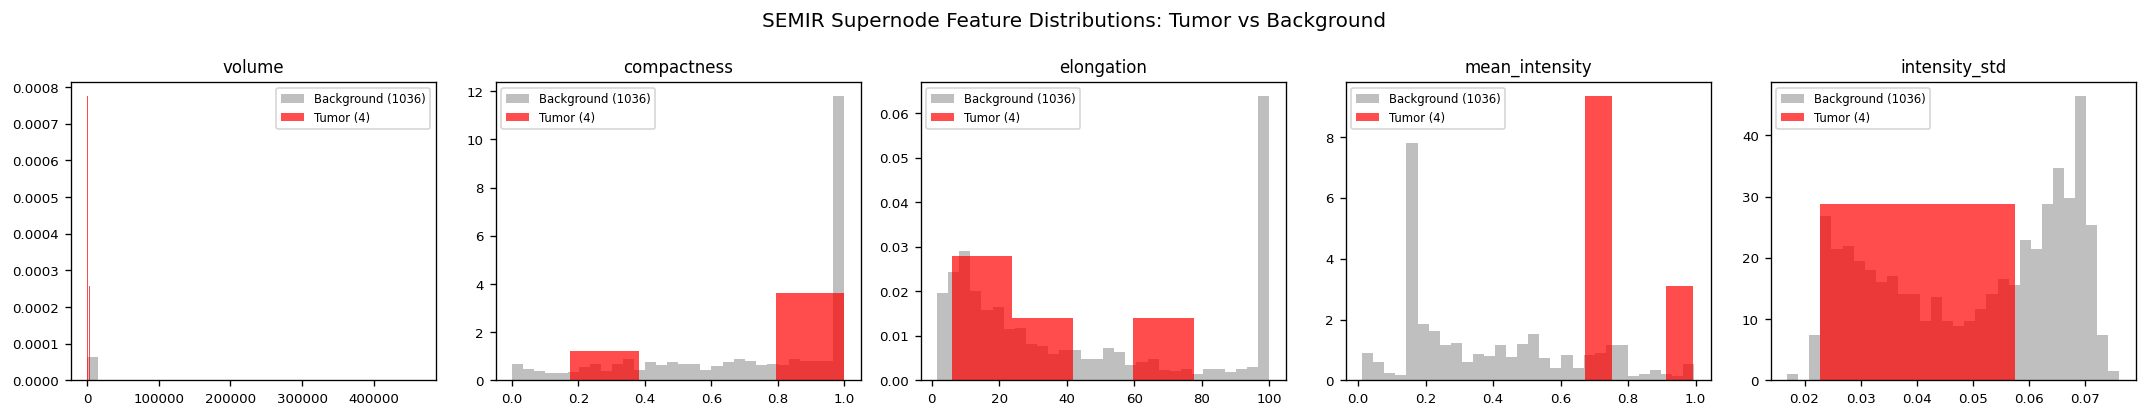


Tumor supernode details:
  SN 228: vol=3,976  compact=0.1752  elong=77.64  intensity=0.9933  tumor_overlap=22.7%
  SN 250: vol=330  compact=1.0000  elong=8.66  intensity=0.6837  tumor_overlap=90.3%
  SN 593: vol=120  compact=1.0000  elong=33.94  intensity=0.7076  tumor_overlap=76.7%
  SN 1008: vol=105  compact=1.0000  elong=5.91  intensity=0.6722  tumor_overlap=69.5%


In [7]:
nf = extract_node_features(labels, ct_norm)

# Separate tumor vs non-tumor features
tumor_feats = {sid: nf[sid] for sid in nf if sid in tumor_sids}
bg_feats = {sid: nf[sid] for sid in nf if sid not in tumor_sids}

feat_names = ["volume", "compactness", "elongation", "mean_intensity", "intensity_std"]
fig, axes = plt.subplots(1, len(feat_names), figsize=(18, 3.5))

for ax, fname in zip(axes, feat_names):
    t_vals = [f[fname] for f in tumor_feats.values()]
    b_vals = [f[fname] for f in bg_feats.values()]
    
    if t_vals:
        ax.hist(b_vals, bins=30, alpha=0.5, label=f"Background ({len(b_vals)})", color="gray", density=True)
        ax.hist(t_vals, bins=min(30, max(3, len(t_vals))), alpha=0.7, label=f"Tumor ({len(t_vals)})", color="red", density=True)
    else:
        ax.hist(b_vals, bins=30, alpha=0.5, label=f"Background ({len(b_vals)})", color="gray", density=True)
    
    ax.set_title(fname, fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

fig.suptitle("SEMIR Supernode Feature Distributions: Tumor vs Background", fontsize=12)
plt.tight_layout()
plt.show()

if tumor_feats:
    print("\nTumor supernode details:")
    for sid, f in sorted(tumor_feats.items()):
        print(f"  SN {sid}: vol={f['volume']:,}  compact={f['compactness']:.4f}  "
              f"elong={f['elongation']:.2f}  intensity={f['mean_intensity']:.4f}  "
              f"tumor_overlap={tumor_frac[sid]:.1%}")

## 5. Parameter sensitivity — beta_min sweep

`beta_min` is the minimum supernode size (in voxels). It controls a critical trade-off:

- **Low beta_min (e.g. 10)**: Keeps small supernodes. Better tumor capture because small
  tumor fragments survive, but the graph has many more nodes (noisier, slower GNN).
- **High beta_min (e.g. 500)**: Only large supernodes survive. Cleaner graph but small
  tumors (or the edges of large tumors) get deleted.

The plots below show:
- **Left**: How supernode count and edge count change with beta_min
- **Right**: What percentage of GT tumor voxels fall inside a surviving tumor supernode

The "sweet spot" is where we get ~1K supernodes with >50% tumor capture.

  beta_min=  10: 17,056 SN, 21,852 edges,  47 tumor SN, capture= 1,991/26,153 (  7.6%)
  beta_min=  50:  2,343 SN, 3,190 edges,   5 tumor SN, capture= 1,441/26,153 (  5.5%)
  beta_min= 100:  1,040 SN, 1,463 edges,   4 tumor SN, capture= 1,365/26,153 (  5.2%)
  beta_min= 200:    454 SN,   639 edges,   2 tumor SN, capture= 1,200/26,153 (  4.6%)
  beta_min= 500:    160 SN,   240 edges,   1 tumor SN, capture=   902/26,153 (  3.4%)


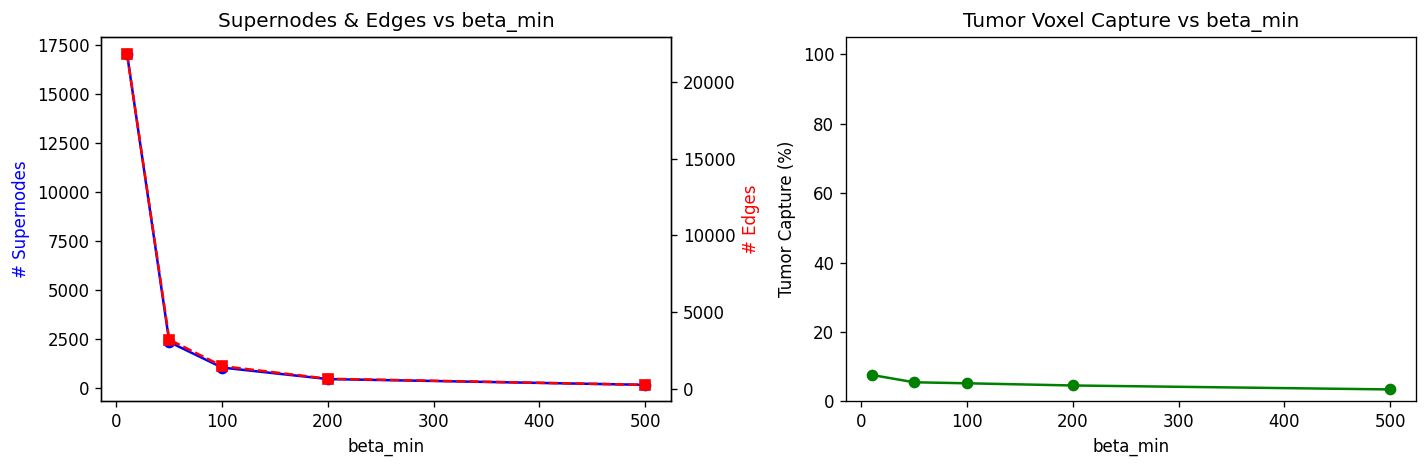

In [8]:
beta_values = [10, 50, 100, 200, 500]
results = []

for bm in beta_values:
    gm_test = build_graph_minor(ct_norm, psi=0.12, alpha=0.12, beta_min=bm,
                                 beta_max=500000, m_min=0.0, m_max=1.0, fast=True)
    lab = gm_test["labels"]
    ml = int(lab.max())
    fl = lab.ravel()
    
    tc = np.bincount(fl, weights=flat_gt_tumor, minlength=ml + 1)
    ttc = np.bincount(fl, minlength=ml + 1)
    sf = np.where(ttc > 0, ttc, 1)
    tf = tc / sf
    
    t_sids = [i for i in range(ml+1) if ttc[i] > 0 and tf[i] > 0.1]
    t_vox = sum(int(tc[i]) for i in t_sids)
    n_sn = gm_test["stats"]["n_supernodes_after_deletion"]
    n_edges = len(gm_test.get("full_adjacency", {}))
    
    results.append({
        "beta_min": bm, "n_sn": n_sn, "n_edges": n_edges,
        "tumor_sn": len(t_sids), "tumor_capture": t_vox,
        "capture_pct": t_vox / max((seg==2).sum(), 1) * 100
    })
    print(f"  beta_min={bm:4d}: {n_sn:>6,} SN, {n_edges:>5,} edges, "
          f"{len(t_sids):>3d} tumor SN, capture={t_vox:>6,}/{(seg==2).sum():,} "
          f"({t_vox/(seg==2).sum()*100:5.1f}%)")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
betas = [r["beta_min"] for r in results]
ax1.plot(betas, [r["n_sn"] for r in results], "o-b")
ax1.set_xlabel("beta_min"); ax1.set_ylabel("# Supernodes", color="b")
ax1r = ax1.twinx()
ax1r.plot(betas, [r["n_edges"] for r in results], "s--r")
ax1r.set_ylabel("# Edges", color="r")
ax1.set_title("Supernodes & Edges vs beta_min")

ax2.plot(betas, [r["capture_pct"] for r in results], "o-g")
ax2.set_xlabel("beta_min"); ax2.set_ylabel("Tumor Capture (%)")
ax2.set_title("Tumor Voxel Capture vs beta_min")
ax2.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 6. Multi-case detection gallery

Run SEMIR on every downloaded case with the same parameters and show side-by-side:
- **Left**: Raw CT slice (at the slice with most tumor)
- **Middle**: Ground truth overlay (blue = pancreas, red = tumor)
- **Right**: SEMIR detection (which supernodes land on tumor vs pancreas)

This shows whether the method generalizes across cases with different tumor sizes,
positions (head/body/tail of pancreas), and imaging conditions.

In [9]:
import re

# Find all downloaded cases that have both CT and segmentation
cases = sorted([
    f.replace(".nii.gz", "")
    for f in os.listdir(os.path.join(DATA_ROOT, "imagesTr"))
    if f.endswith(".nii.gz") and os.path.exists(
        os.path.join(DATA_ROOT, "labelsTr", f))
])
print(f"Available cases: {len(cases)}")

# Run the SEMIR pipeline on each case with identical parameters.
# For each case we:
#   1. Load CT + seg
#   2. Normalize with [20, 180] HU window
#   3. Build graph minor (edge contraction -> node deletion -> edge deletion)
#   4. Check which supernodes overlap with GT tumor/pancreas
case_results = []
for cname in cases:
    ct_i = nib.load(os.path.join(DATA_ROOT, "imagesTr", f"{cname}.nii.gz")).get_fdata().astype(np.float32)
    seg_i = nib.load(os.path.join(DATA_ROOT, "labelsTr", f"{cname}.nii.gz")).get_fdata().astype(np.int32)
    sp_i = tuple(float(s) for s in nib.load(os.path.join(DATA_ROOT, "imagesTr", f"{cname}.nii.gz")).header.get_zooms()[:3])
    
    ct_n = np.clip(ct_i, 20, 180)
    ct_n = (ct_n - 20) / 160.0
    
    gm_i = build_graph_minor(ct_n, psi=0.12, alpha=0.12, beta_min=100,
                              beta_max=500000, m_min=0.0, m_max=1.0, fast=True)
    
    # Evaluate supernode-GT overlap (same logic as Section 2)
    lab_i = gm_i["labels"]
    ml_i = int(lab_i.max())
    fl_i = lab_i.ravel()
    ft_i = (seg_i.ravel() == 2).astype(np.float64)
    
    tc_i = np.bincount(fl_i, weights=ft_i, minlength=ml_i + 1)
    ttc_i = np.bincount(fl_i, minlength=ml_i + 1)
    sf_i = np.where(ttc_i > 0, ttc_i, 1)
    tf_i = tc_i / sf_i
    
    t_sids_i = set(i for i in range(ml_i+1) if ttc_i[i] > 0 and tf_i[i] > 0.1)
    p_sids_i = set(i for i in range(ml_i+1) if ttc_i[i] > 0 and
                   np.bincount(fl_i, weights=(seg_i.ravel() == 1).astype(np.float64), minlength=ml_i + 1)[i] / sf_i[i] > 0.1)
    
    # Pick the slice with the most tumor for visualization
    tps = (seg_i == 2).sum(axis=(0, 1))
    bs = int(np.argmax(tps))
    
    case_results.append({
        "name": cname, "ct_raw": ct_i, "seg": seg_i, "labels": lab_i,
        "tumor_sids": t_sids_i, "pancreas_sids": p_sids_i,
        "best_slice": bs, "stats": gm_i["stats"],
        "tumor_capture": sum(int(tc_i[s]) for s in t_sids_i),
        "gt_tumor": int((seg_i == 2).sum()),
    })
    cap_pct = case_results[-1]['tumor_capture'] / max(case_results[-1]['gt_tumor'], 1) * 100
    print(f"  {cname}: {gm_i['stats']['n_supernodes_after_deletion']:,} SN, "
          f"{len(t_sids_i)} tumor SN, "
          f"capture={case_results[-1]['tumor_capture']:,}/{case_results[-1]['gt_tumor']:,} "
          f"({cap_pct:.1f}%)")

Available cases: 5
  pancreas_001: 1,040 SN, 4 tumor SN, capture=1,365/26,153 (5.2%)
  pancreas_004: 1,053 SN, 8 tumor SN, capture=4,484/28,448 (15.8%)
  pancreas_005: 538 SN, 1 tumor SN, capture=34/3,609 (0.9%)
  pancreas_006: 847 SN, 1 tumor SN, capture=107/9,244 (1.2%)
  pancreas_010: 1,041 SN, 3 tumor SN, capture=7,251/53,193 (13.6%)


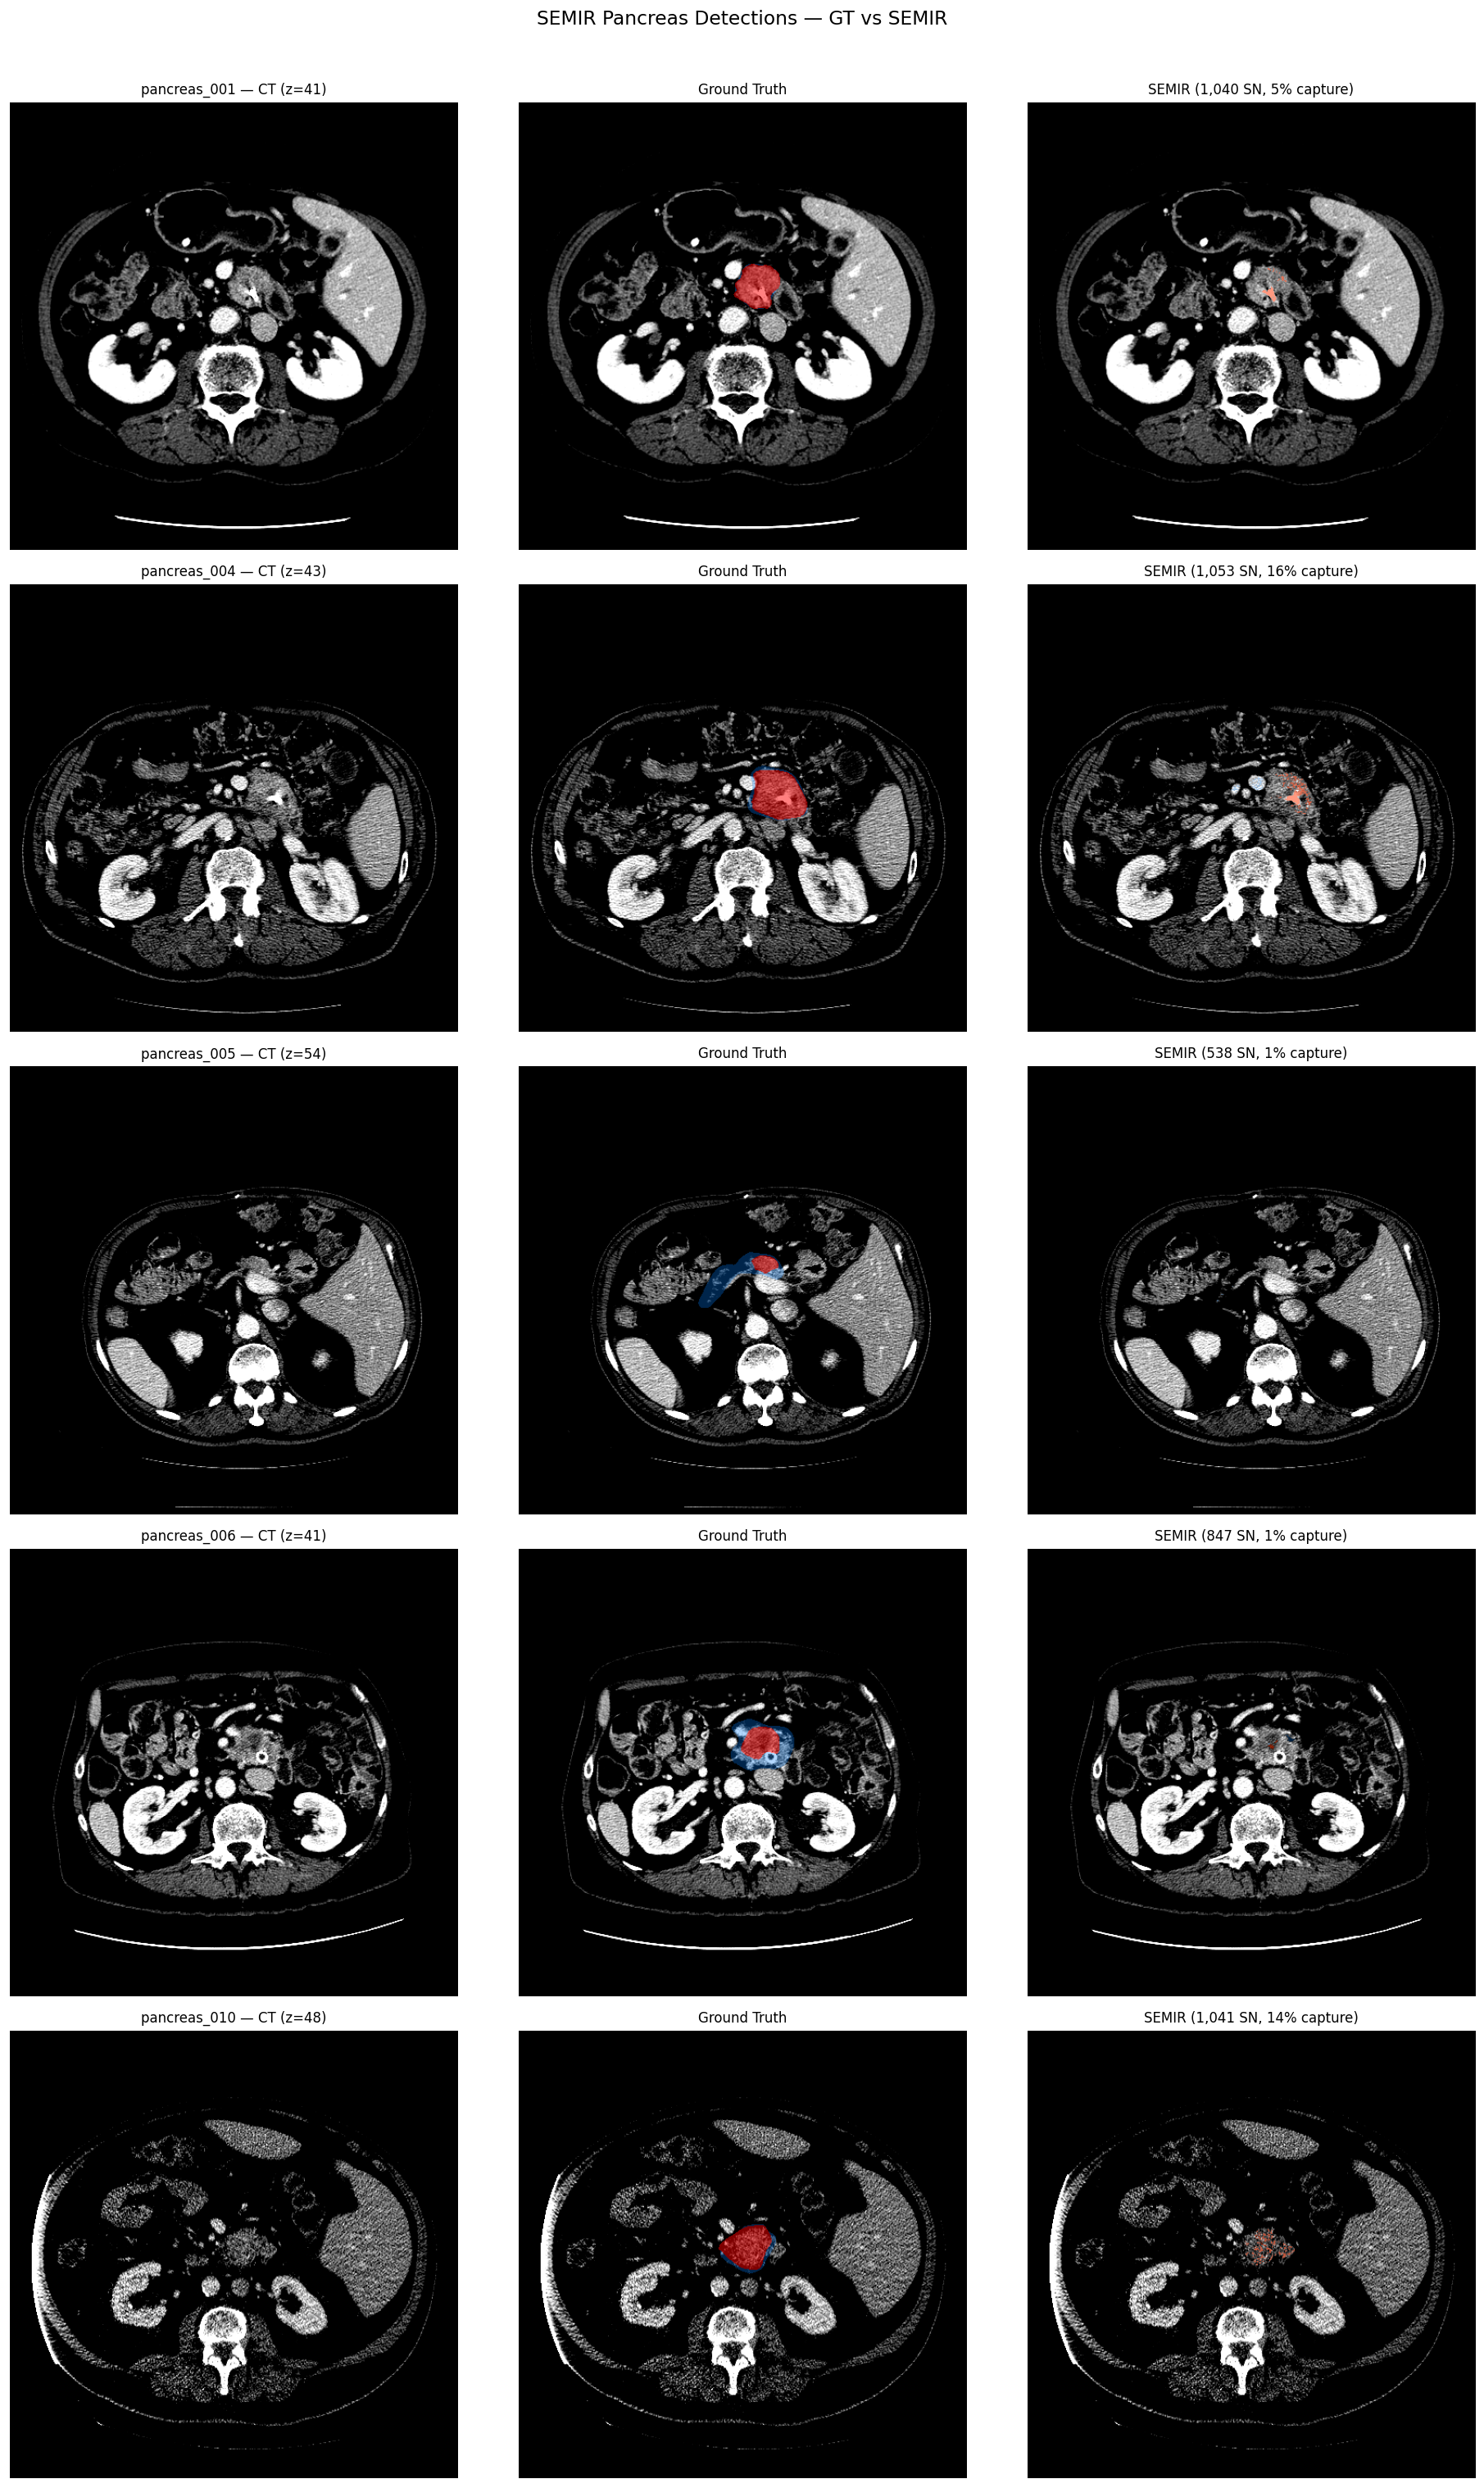

In [10]:
# Gallery: GT vs SEMIR detection for each case
n_cases = len(case_results)
fig, axes = plt.subplots(n_cases, 3, figsize=(16, 5 * n_cases))
if n_cases == 1:
    axes = axes[np.newaxis, :]

for row, cr in enumerate(case_results):
    sl = cr["best_slice"]
    ct_sl = cr["ct_raw"][:, :, sl]
    seg_sl = cr["seg"][:, :, sl]
    lab_sl = cr["labels"][:, :, sl]
    
    # Panel 1: CT
    axes[row, 0].imshow(ct_sl.T, cmap="gray", vmin=20, vmax=180, origin="lower")
    axes[row, 0].set_title(f"{cr['name']} — CT (z={sl})", fontsize=10)
    axes[row, 0].axis("off")
    
    # Panel 2: GT overlay
    axes[row, 1].imshow(ct_sl.T, cmap="gray", vmin=20, vmax=180, origin="lower")
    ov = np.zeros((*ct_sl.T.shape, 4))
    ov[seg_sl.T == 1] = [0, 0.5, 1, 0.3]
    ov[seg_sl.T == 2] = [1, 0, 0, 0.5]
    axes[row, 1].imshow(ov, origin="lower")
    axes[row, 1].set_title("Ground Truth", fontsize=10)
    axes[row, 1].axis("off")
    
    # Panel 3: SEMIR detections
    axes[row, 2].imshow(ct_sl.T, cmap="gray", vmin=20, vmax=180, origin="lower")
    det = np.zeros((*ct_sl.T.shape, 4))
    for y in range(lab_sl.shape[0]):
        for x in range(lab_sl.shape[1]):
            sid = lab_sl[y, x]
            if sid in cr["tumor_sids"]:
                det[x, y] = [1, 0.2, 0, 0.5]
            elif sid in cr["pancreas_sids"]:
                det[x, y] = [0, 0.5, 1, 0.25]
    axes[row, 2].imshow(det, origin="lower")
    cap = cr["tumor_capture"] / max(cr["gt_tumor"], 1) * 100
    axes[row, 2].set_title(f"SEMIR ({cr['stats']['n_supernodes_after_deletion']:,} SN, "
                            f"{cap:.0f}% capture)", fontsize=10)
    axes[row, 2].axis("off")

fig.suptitle("SEMIR Pancreas Detections — GT vs SEMIR", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. SEMIR phenotypes vs GT CSV — the whole point

This is the validation that matters: can SEMIR produce the **same numbers** that
`Pancreas_Tumor_Analysis.csv` contains?

The CSV has these columns (computed from GT masks by a separate script):
- `Tumor Volume` (voxels)
- `Pancreas Volume` (voxels)
- `Tumor Coverage (%)` = tumor_vol / pancreas_vol
- `Distance (voxels)` = centroid distance

SEMIR derives the same quantities from its supernodes — no GT needed.
If the SEMIR values are close to the CSV values, the VKG pipeline can
switch from `vkg_from_csv.py` to `vkg_builder.py` and get equivalent results.

In [11]:
import pandas as pd

CSV_PATH = "/home/ud3d4/Desktop/Projects/acm_mmkg/data/Pancreas_Tumor_Analysis.csv"
csv_df = pd.read_csv(CSV_PATH)

# Match cases
comparison = []
for cr in case_results:
    cname = cr["name"]  # e.g. pancreas_001
    csv_row = csv_df[csv_df["CT Scan"].str.contains(cname.replace("pancreas_", "pancreas_"))]
    if csv_row.empty:
        continue
    csv_row = csv_row.iloc[0]
    
    # SEMIR-derived: aggregate tumor supernodes
    lab = cr["labels"]
    nf_i = extract_node_features(lab, np.clip(cr["ct_raw"], 20, 180) / 160.0)
    
    semir_vol = sum(nf_i[s]["volume"] for s in cr["tumor_sids"] if s in nf_i)
    semir_pancreas_vol = sum(nf_i[s]["volume"] for s in cr["pancreas_sids"] if s in nf_i)
    semir_coverage = semir_vol / max(semir_pancreas_vol + semir_vol, 1) * 100
    
    comparison.append({
        "case": cname,
        "csv_tumor_vol": int(csv_row["Tumor Volume"]),
        "semir_tumor_vol": semir_vol,
        "csv_pancreas_vol": int(csv_row["Pancreas Volume"]),
        "semir_pancreas_vol": semir_pancreas_vol,
        "csv_coverage": float(csv_row["Tumor Coverage (%)"]),
        "semir_coverage": semir_coverage,
        "csv_distance": float(csv_row["Distance (voxels)"]),
    })

if comparison:
    comp_df = pd.DataFrame(comparison)
    print("SEMIR vs GT CSV comparison:")
    print(comp_df.to_string(index=False))
else:
    print("No matching cases found between downloaded data and CSV")

SEMIR vs GT CSV comparison:
        case  csv_tumor_vol  semir_tumor_vol  csv_pancreas_vol  semir_pancreas_vol  csv_coverage  semir_coverage  csv_distance
pancreas_001           6533             4531              9902                2547     65.976570       64.015259     29.447783
pancreas_004           7117            10739             17877               30522     39.810930       26.026999     38.274346
pancreas_005            904              270             17754                2655      5.091810        9.230769     14.807724
pancreas_006           2314              107             17527                5253     13.202488        1.996269     15.005564
pancreas_010          13294            16034             29161               20606     45.588286       43.760917     43.692263
